<img src=https://lh4.googleusercontent.com/proxy/WNtyuTbDjnnITJFxg1dlI63L0jfIMRf0CIKg75VavFd3ameUuokpEiXIZvafO0UbA3rGKkhjDZ2HFtRWcGiPIn7Syd37PqnCrQuXFNHguRRPYm__safRJi9Q width="300"/>

# **Predicción de Incumplimiento del Crédito con Redes Neuronales**

En este notebook se desarrolla un modelo para predecir la probabilidad de que un individuo incumpla con el pago de su crédito a partir de características del cliente y su historial crediticio.

**Profesor:** Juan David Ospina

**Monitor:** Andrés Mauricio Zapata

**Integrantes:** Tomás Acevedo Roldán, Santiago Cardona Franco, Jimena Hernández Castillo

**Introducción a Redes Neuronales y Algoritmos Bioinspirados** - Semestre 2026-01

**Universidad Nacional de Colombia (Facultad de Minas)**


## **Descripción del problema**
El riesgo crediticio es uno de los mayores desafíos en la industria financiera. Esto debido a que entidades bancarias requieren evaluar la probabilidad de que un cliente **incumpla con el pago de su crédito** antes de concederlo.

El objetivo de la actividad es estimar la probabilidad de que un cliente sea **"mal pagador"** (valor 1) usando el dataset [*Credit Risk Dataset* de Kaggle](https://www.kaggle.com/datasets/ranadeep/credit-risk-dataset/data).

### **Variable objetivo**
La variable `loan_status` es transformada en una variable binaria:
- **0** → Buen pagador (pagó su crédito completamente)
- **1** → Mal pagador (no pagó su crédito)
- **NA** → Casos excluidos del entrenamiento (no se tiene certeza sobre si el cliente es buen o mal pagador).

## **1. Importación de librerías y carga de datos**

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow imbalanced-learn --quiet
!pip install kagglehub[pandas-datasets]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub
import itertools
import random
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score, recall_score, precision_score
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from kagglehub import KaggleDatasetAdapter

#Fijamos las semillas para que los códigos sean reproducibles y obtenga el mismo resultado en cada ejecución
SEED = 42
random.seed(SEED) # Python
np.random.seed(SEED)  # NumPy
tf.random.set_seed(SEED)  # TensorFlow/Keras
os.environ['PYTHONHASHSEED'] = str(SEED) # Hashing de Python
# Rutas
os.makedirs('./output/figs', exist_ok=True)
os.makedirs('./output/models', exist_ok=True)
output_dir = './output/figs'
model_dir = './output/models'

#Con esto hacemos el entrenamiento más determinístico, aunque se sacrifique capacidad de cómputo
tf.config.experimental.enable_op_determinism()

c:\Users\USUARIO\Documents\Clases\2026_1\RNA y Algo. Bioinsp\RNAAB_T02\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carga de datos
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
  "ranadeep/credit-risk-dataset", "loan/loan.csv")
print("Tamaño del Dataset:", df.shape)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13912\992411584.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
c:\Users\USUARIO\Documents\Clases\2026_1\RNA y Algo. Bioinsp\RNAAB_T02\.venv\Lib\site-packages\kagglehub\pandas_datasets.py:92: DtypeWarning: Columns (0: desc, 1: verification_status_joint) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


Tamaño del Dataset: (887379, 74)


## **2. Preprocesamiento y limpieza de los datos**

In [3]:
# Definición de la variable objetivo

# Mapeamos la variable loan_status de String a binaria según nuestras necesidades (1:mal pagador, 0:buen pagador, NA: casos excluidos del entrenamiento)
mapa_de_estado = {
    'Fully Paid': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Charged Off': 1,
    'Late (31-120 days)': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Charged Off': 1,
    'Current': np.nan,
    'Issued': np.nan,
    'In Grace Period': np.nan,
    'Late (16-30 days)': np.nan,
}

#En la columna 'target' almacenamos nuestra variable objetivo
df['target'] = df['loan_status'].map(mapa_de_estado)

# Eliminar los casos que no nos sirven para el modelo (NA en target)
df_modelo = df.dropna(subset=['target']).copy()
#Cambiamos el tipo de dato de la variable objetivo a entero
df_modelo['target'] = df_modelo['target'].astype(int)

print("Distribución de la variable objetivo:")
print(df_modelo['target'].value_counts())
#El promedio nos sirve para observar el porcentaje de malos pagadores
print(f"\nProporción de malos pagadores: {df_modelo['target'].mean():.2%}")
print(f"Proporción de buenos pagadores: {1-df_modelo['target'].mean():.2%}")
print(f"\nRegistros para modelar: {df_modelo.shape[0]:,}")

Distribución de la variable objetivo:
target
0    209711
1     58819
Name: count, dtype: int64

Proporción de malos pagadores: 21.90%
Proporción de buenos pagadores: 78.10%

Registros para modelar: 268,530


In [4]:
# Eliminación de columnas con demasiados nulos o con poco valor para la predicción de valores

# Definimos nuestro umbral para eliminar las columnas con 50%+ de nulos
umbral = 0.5
nulos = df_modelo.isnull().mean()
#Tomamos los nombres de las columnas a eliminar de nuestro Dataframe por pasarse del umbral
cols_drop_nulos = nulos[nulos >= umbral].index.tolist()

#Se eliminarán a su vez aquellas columnas que no aportan información relevante para la predicción
#del modelo, incluyendo 'loan_status' que ya no la necesitamos pues incluímos la columna 'target' como variable objetivo
cols_drop_id = [
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'addr_state', 'next_pymnt_d', 
    'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'total_pymnt','total_pymnt_inv', 
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 
    'funded_amnt', 'funded_amnt_inv', 'policy_code', 'issue_d', 'loan_status', 'emp_title', 'revol_bal',
    'out_prncp', 'out_prncp_inv', 'grade', 'sub_grade', 'earliest_cr_line', 'installment',
    'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim'
]

#Fusionamos ambos criterios en una lista de columnas a eliminar
cols_to_drop = list(set(cols_drop_nulos + cols_drop_id))

#Y finalmente las borramos del Dataset para nuestro modelo
df_modelo = df_modelo.drop(columns=[c for c in cols_to_drop if c in df_modelo.columns])

#Verificamos la cantidad de columnas eliminadas y restantes del Dataset, junto con el cambio que esta trae en su tamaño
print(f"Columnas eliminadas por nulos: {len(cols_drop_nulos)}")
print(f"Columnas eliminadas por ser irrelevantes: {len(cols_drop_id)}")
print(f"Columnas restantes: {df_modelo.shape[1]}")
print(f"Tamaño final del Dataset: {df_modelo.shape}")

Columnas eliminadas por nulos: 22
Columnas eliminadas por ser irrelevantes: 36
Columnas restantes: 19
Tamaño final del Dataset: (268530, 19)


Ahora, haremos la separación de variables numéricas y categóricas, para que el modelo sepa como comportarse según el tipo de dato de cada columna.

In [5]:
# Excluimos la variable objetivo
caracteristicas = [c for c in df_modelo.columns if c != 'target']

# Separamos las columnas por tipo de dato
num_cols = df_modelo[caracteristicas].select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_modelo[caracteristicas].select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(num_cols)}):")
print(num_cols)
print(f"\nVariables categóricas ({len(cat_cols)}):")
print(cat_cols)

Variables numéricas (10):
['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc']

Variables categóricas (8):
['term', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'initial_list_status', 'application_type']


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13912\1559057750.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_modelo[caracteristicas].select_dtypes(include=['object']).columns.tolist()


En total podemos observar que hay 18 variables sin contar la variable objetivo 'target'. Para nuestro caso, y en búsqueda de mantener una gran cantidad de registros disponibles sin reducirlos abruptamente, hemos optado por implantar ciertos valores específicos para los valores nulos que se tengan en el Dataframe según la naturaleza del tipo de dato presente en cada columna. Para los datos numéricos usaremos la mediana de los datos de la columna, mientras que para los datos categóricos, elegiremos la moda.

In [6]:
# Para las variables numéricas → mediana (la elegimos pues es una opción robusta frente a los outliers)
for col in num_cols:
    mediana = df_modelo[col].median()
    df_modelo[col] = df_modelo[col].fillna(mediana)

#Para las variables categóricas → moda
for col in cat_cols:
    moda = df_modelo[col].mode()[0] #Si existen varias modas, se toma la primera (la menor)
    df_modelo[col] = df_modelo[col].fillna(moda)

print(f"Cantidad de valores nulos restantes: {df_modelo.isnull().sum().sum()}") #Doble suma por tener dos dimensiones el Dataframe

Cantidad de valores nulos restantes: 0


Ahora nuestro Dataframe está libre de valores nulos y está casi listo para ser utilizado, únicamente falta codificar las variable categóricas para que la red pueda tomar valores numéricos de todas las columnas y se puede entrenar correctamente. Para esto, debemos validar si una variable es **ordinal** (tiene un orden lógico) o **nominal** (es solo una etiqueta).

In [7]:
# Transformación de 'term' a numérico
if 'term' in df_modelo.columns:
    df_modelo['term'] = df_modelo['term'].str.extract(r'(\d+)').astype(int)

# Transformación de 'emp_length' a ordinal
emp_len_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
if 'emp_length' in df_modelo.columns:
    df_modelo['emp_length'] = df_modelo['emp_length'].map(emp_len_map).fillna(0).astype(int)

# One-Hot Encoding para el resto de nominales
nominal_cols = df_modelo.select_dtypes(include=['object', 'string']).columns.tolist()
df_modelo = pd.get_dummies(df_modelo, columns=nominal_cols, drop_first=True)

# Convertir booleanos resultantes a int (0/1)
bool_cols = df_modelo.select_dtypes(include=['bool']).columns
df_modelo[bool_cols] = df_modelo[bool_cols].astype(int)

# Limpieza final de posibles nulos remanentes tras las conversiones
df_modelo = df_modelo.fillna(df_modelo.median())

print(f"\nProcesamiento completado.")
print(f"Tamaño final: {df_modelo.shape}")
print(f"Columnas del dataset:")
print(df_modelo.columns.tolist())


Procesamiento completado.
Tamaño final: (268530, 36)
Columnas del dataset:
['loan_amnt', 'term', 'int_rate', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'target', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'pymnt_plan_y', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'initial_list_status_w', 'application_type_JOINT']


## **3. Análisis descriptivo y elaboración de hipótesis**

En este paso, buscamos entender los datos antes de generar el modelo, para que cuando lo realicemos este no carezca de sentido lógico o estructural, lo cual nos puede brindar mejores resultados al tener mayor dominio del problema. De igual manera se podrán plantear hipótesis sobre que variables se consideran más importantes o menos importantes a la hora de predecir si un determinado cliente cumplirá o inclumplirá con el pago de su crédito.

Para lograr esto, nos enfocaremos en observar que tan desbalanceado está el Dataset entre buenos y malos pagadores para entender qué técnicas especiales necesitaremos para entrenar el modelo, además de comparar como se distribuyen variables numéricas entre buenos y malos pagadores para comprender que variables pueden ser más útiles para el modelo, lo mismo con las variables categóricas. Y finalmente, para comprender cuales son las correlaciones entre las variables y con el target, la cuales pueden favorecer o sabotear el proceso de aprendizaje del modelo.

Empezaremos observando la distribución de los valores del target.

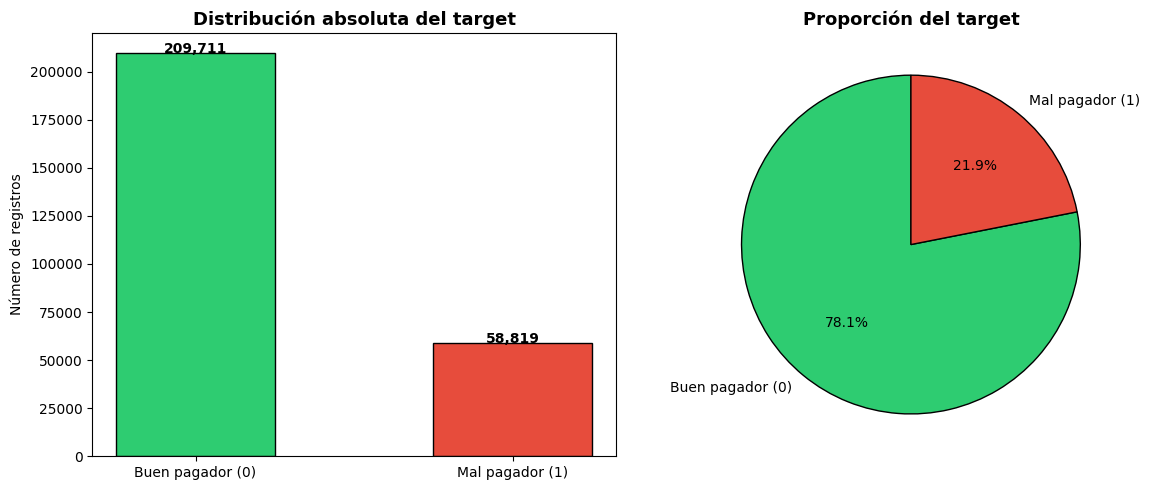

In [8]:
# Distribución del target

# Conteos y proporciones
conteos = df_modelo['target'].value_counts()
proporciones = df_modelo['target'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1 — Conteo absoluto
axes[0].bar(['Buen pagador (0)', 'Mal pagador (1)'],
            conteos.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.5)
axes[0].set_title('Distribución absoluta del target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de registros')
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Gráfico 2 — Proporción
axes[1].pie(proporciones.values,
            labels=['Buen pagador (0)', 'Mal pagador (1)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proporción del target', fontsize=13, fontweight='bold')

#plt.suptitle('Figura 1. Distribución de la variable objetivo',
#             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fr'{output_dir}/fig1_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

Ahora pasaremos a analizar las variables numéricas vs el target.

Compararemos cómo se distribuyen las variables numéricas más importantes entre buenos y malos pagadores usando boxplots. Si una variable tiene distribuciones diferentes entre las dos clases, es una buena señal de que será útil para la elaboración del modelo.


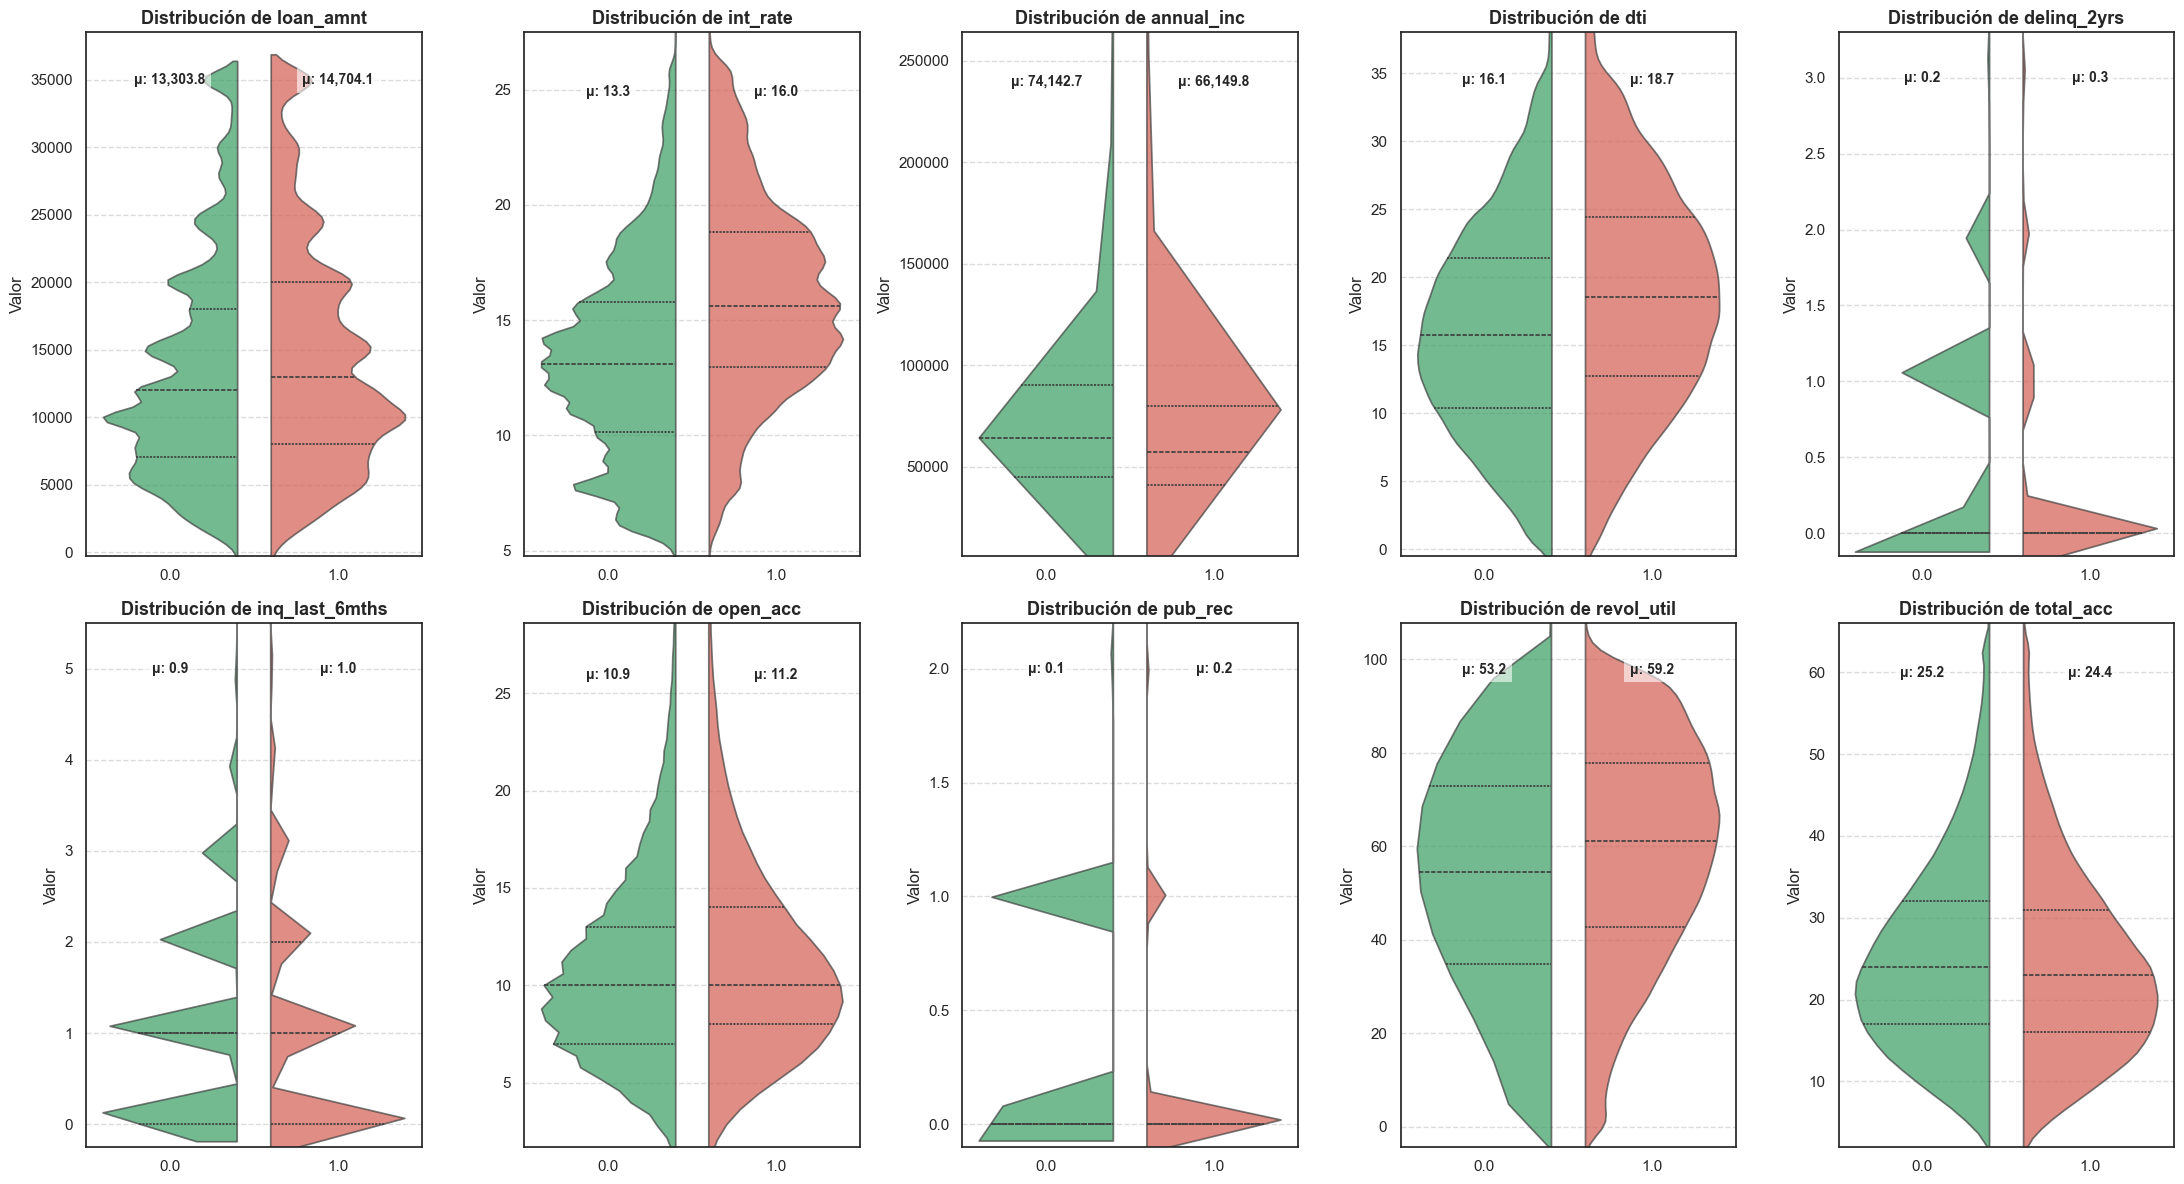

In [14]:
# Variables numéricas
vars_numericas = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc']

# Configuración de estilo
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 5, figsize=(22, 12))
axes = axes.flatten()

# Colores Verde para Buen Pagador (0), Rojo para Mal Pagador (1)
paleta = {0: '#27ae60', 1: '#e74c3c'}
labels_map = {0: 'Buen pagador', 1: 'Mal pagador'}

for i, var in enumerate(vars_numericas):
    ax = axes[i]
    
    # 1. Preparación de datos
    temp = df[[var, 'target']].dropna()
    
    # 2. Definición de límites para evitar que los outliers arruinen la visualización
    # Si la variable tiene valores muy extremos, cortamos en el percentil 95 o 99
    limite_superior = temp[var].quantile(0.99)
    limite_inferior = temp[var].quantile(0.01)
    
    # 3. Gráfico de Violín
    sns.violinplot(data=temp, x='target', y=var, hue='target',
                   palette=paleta, split=True, inner="quart", ax=ax, alpha=0.7, legend=False)
    
    # 4. Ajuste de escala y títulos (Zoom dinámico)
    ax.set_ylim(limite_inferior - (limite_superior*0.05), limite_superior * 1.1)
    ax.set_title(f'Distribución de {var}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Valor')

    # 5. Cálculo y anotación de medias (Puntual y claro)
    medias = temp.groupby('target')[var].mean()
    for j, (target_val, media) in enumerate(medias.items()):
        # Colocamos el texto de la media en la parte superior del violín
        ax.text(j, ax.get_ylim()[1] * 0.9, f'μ: {media:,.1f}', 
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    # Añadir cuadrícula horizontal sutil
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Ajuste final de la figura
plt.tight_layout()

# Guardar con la misma calidad que el anterior
plt.savefig(fr'{output_dir}/fig2_numericas_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

De la misma manera analizaremos las variables categóricas vs el target.

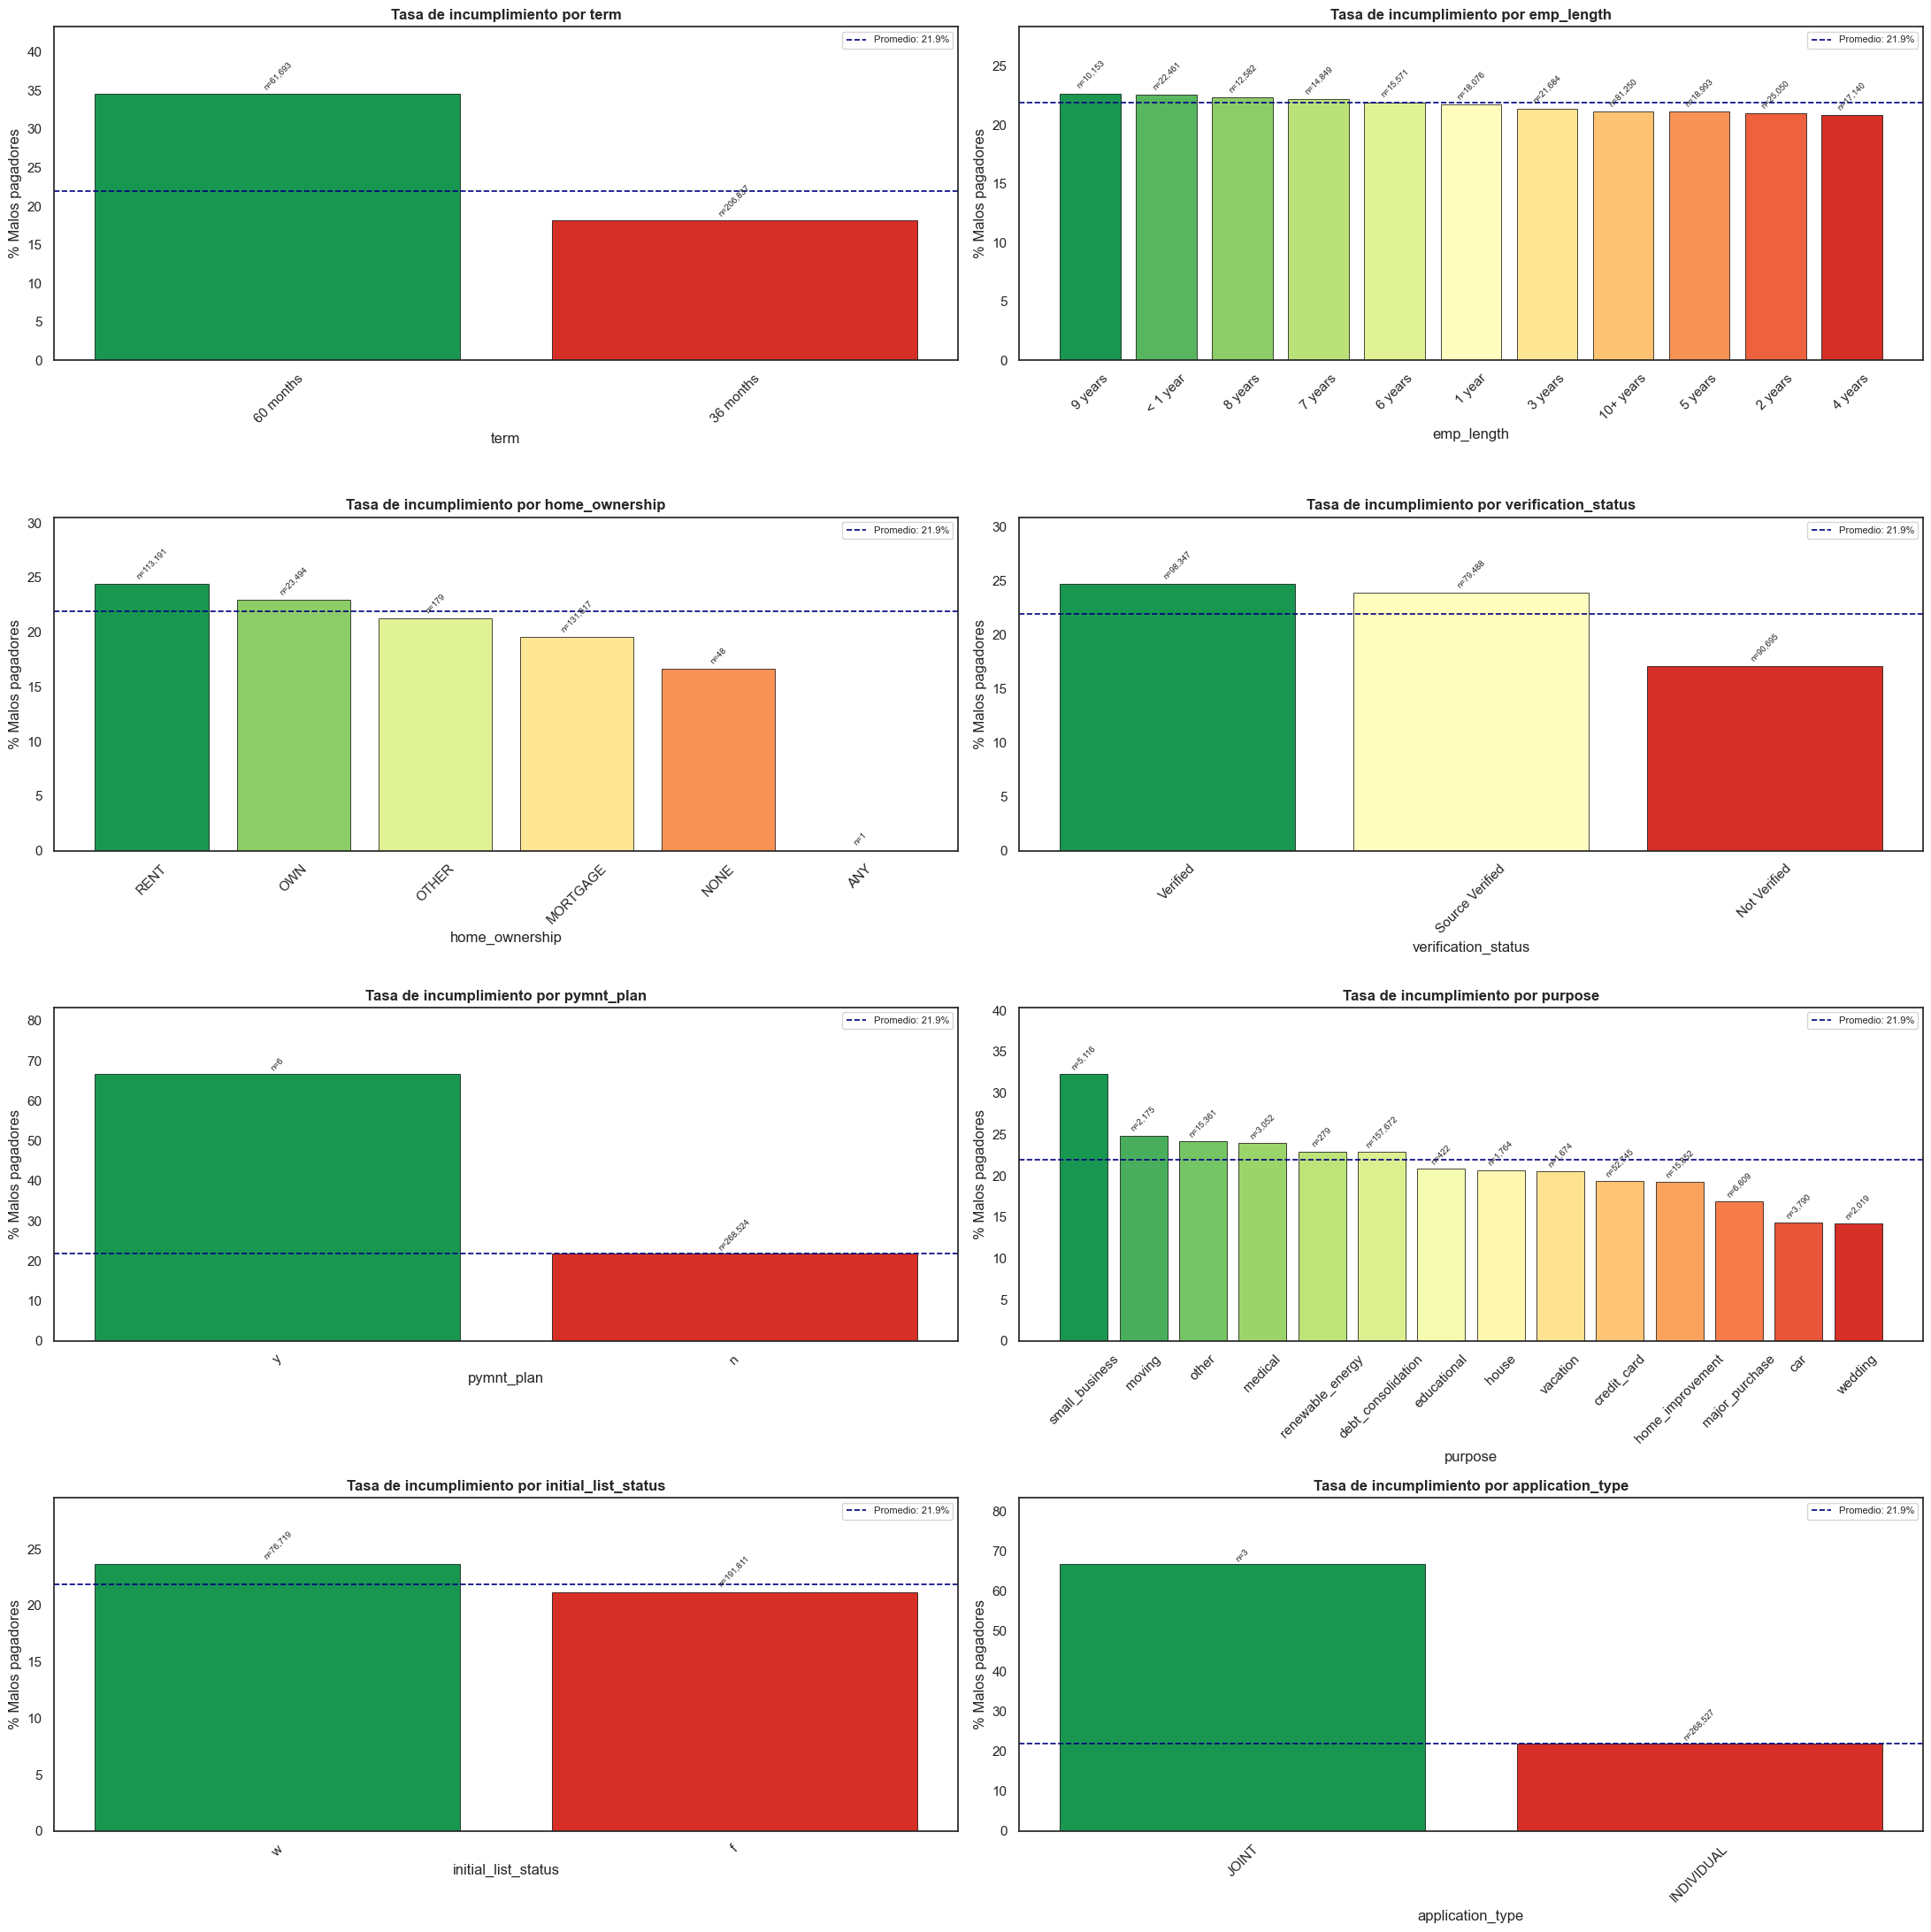

In [15]:
# Recuperamos las columnas originales antes del encoding
# Trabajaremos con df_modelo pero reconstruyendo las categóricas desde df
cat_vars_analisis = ['term', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'initial_list_status', 'application_type']

fig, axes = plt.subplots(4, 2, figsize=(22, 22))
axes = axes.flatten()

for i, var in enumerate(cat_vars_analisis):
    ax = axes[i]

    # Reconstruimos la variable original desde df (antes del encoding)
    temp = df[[var, 'loan_status']].copy()
    temp['target'] = df['loan_status'].map(mapa_de_estado)
    temp = temp[temp['target'].notna()]
    temp['target'] = temp['target'].astype(int)

    # Calculamos tasa de incumplimiento por categoría
    tasa = temp.groupby(var)['target'].mean().sort_values(ascending=False) * 100
    conteo = temp.groupby(var)['target'].count()

    colores = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(tasa)))

    bars = ax.bar(tasa.index, tasa.values, color=colores, edgecolor='black', linewidth=0.5)

    # Añadimos el n de cada categoría sobre cada barra
    for bar, cat in zip(bars, tasa.index):
        n = conteo[cat]
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'n={n:,}',
                ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_title(f'Tasa de incumplimiento por {var}', fontsize=12, fontweight='bold')
    ax.set_ylabel('% Malos pagadores')
    ax.set_xlabel(var)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, tasa.max() * 1.25)

    # Línea de referencia: tasa global
    tasa_global = df_modelo['target'].mean() * 100
    ax.axhline(tasa_global, color='navy', linestyle='--', linewidth=1.2, label=f'Promedio: {tasa_global:.1f}%')
    ax.legend(fontsize=8)

# plt.suptitle('Figura 3. Tasa de incumplimiento por variable categórica',
#              fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(fr'{output_dir}/fig3_categoricas_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

Finalmente estudiaremos la correlación entre las variables con el target y entre las variables numéricas.

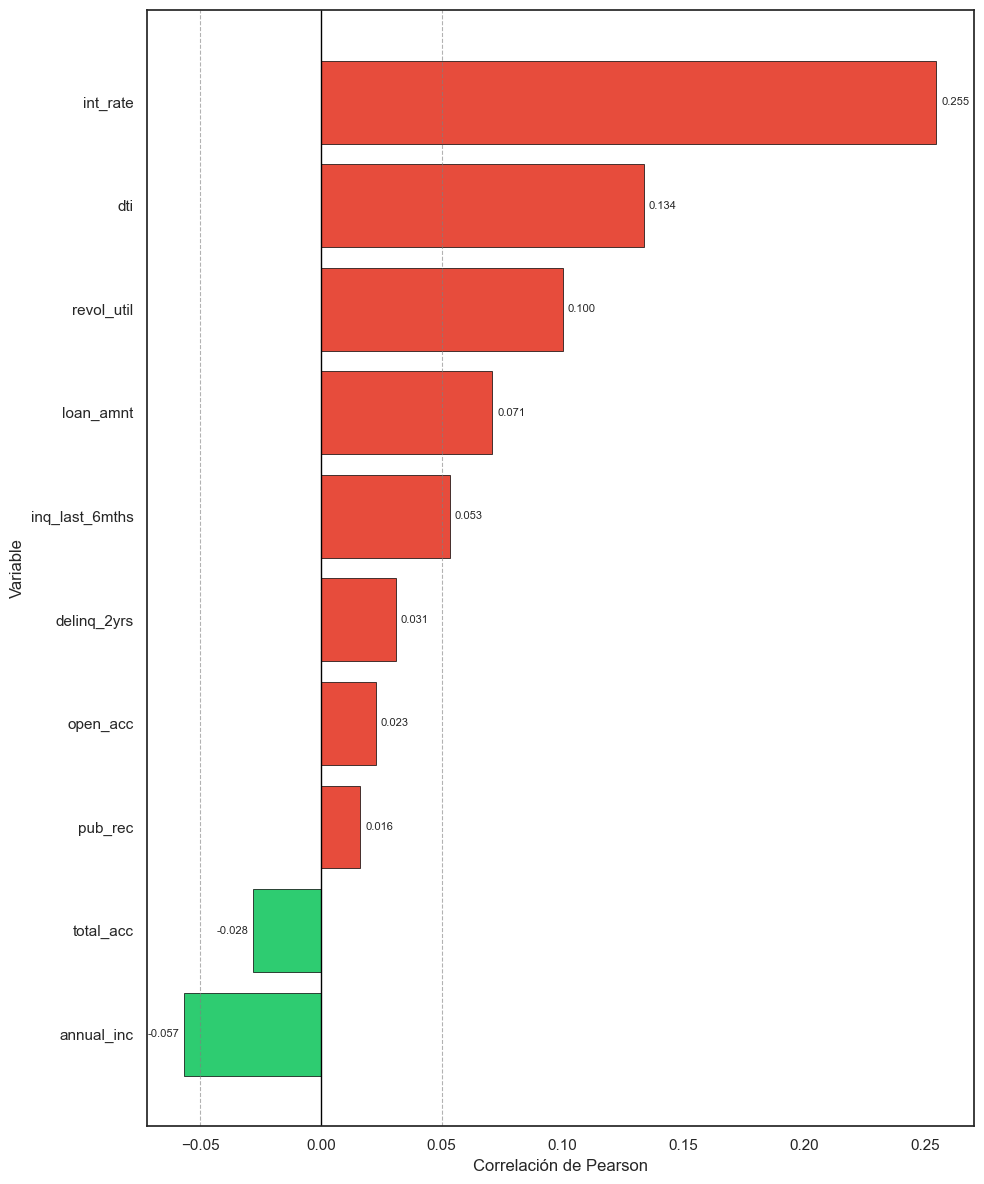

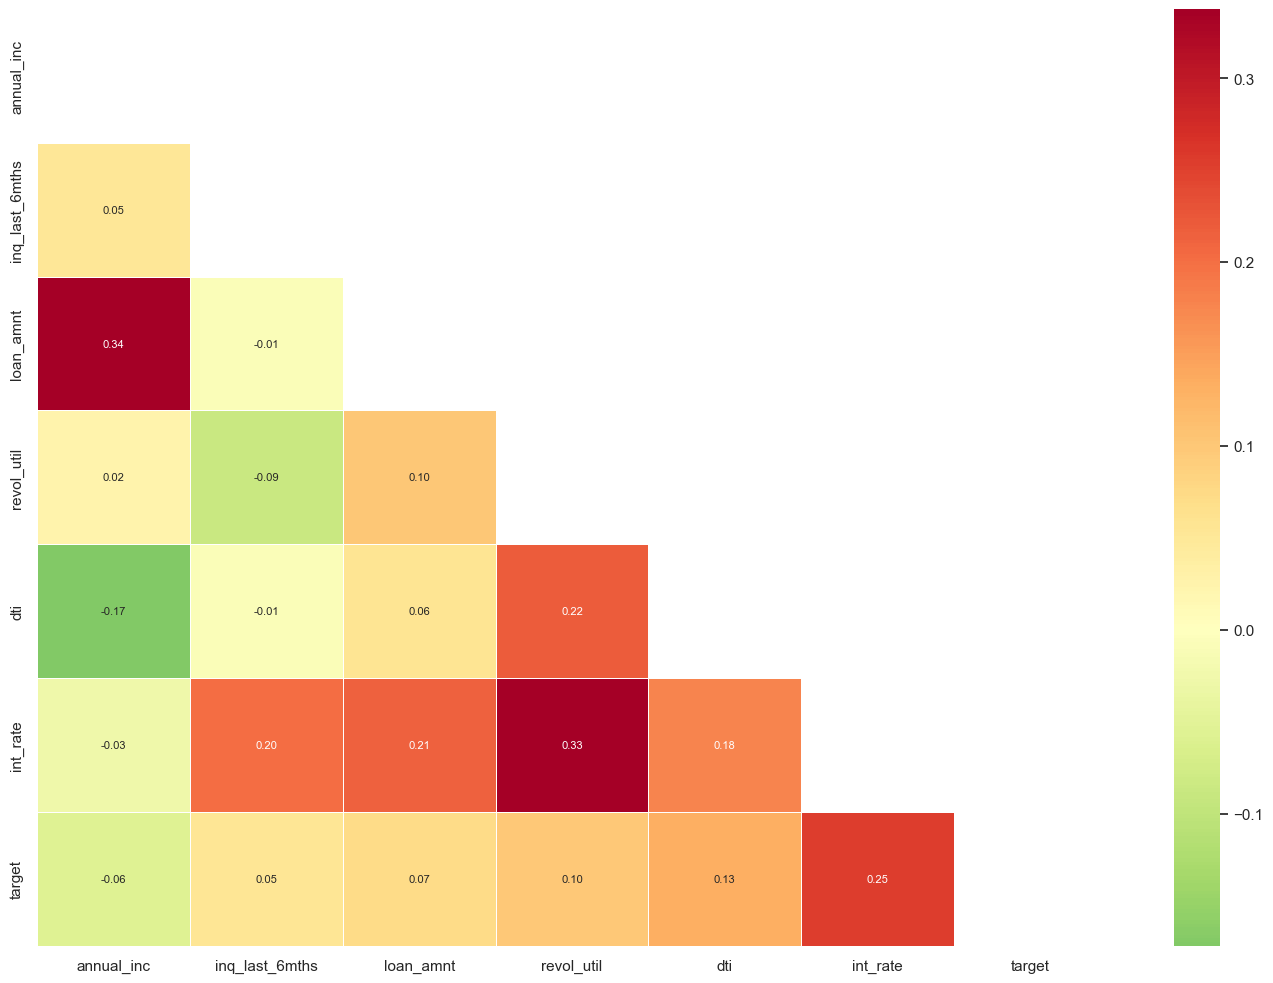


Top 10 variables más correlacionadas con el target:
int_rate          0.254779
dti               0.133670
revol_util        0.100091
loan_amnt         0.071006
annual_inc        0.056560
inq_last_6mths    0.053429
delinq_2yrs       0.031149
total_acc         0.028114
open_acc          0.022789
pub_rec           0.016356


In [16]:
# Tomamos solo las variables numéricas originales + target
vars_correlacion = num_cols + ['target']
df_corr = df_modelo[vars_correlacion].copy()

# --- Gráfico 1: Correlaciones con el target (barras horizontales) ---
correlaciones_target = df_corr.corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(10, 12))

colores = ['#e74c3c' if v > 0 else '#2ecc71' for v in correlaciones_target.values]
bars = ax.barh(correlaciones_target.index, correlaciones_target.values,
               color=colores, edgecolor='black', linewidth=0.5)

ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.05, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(-0.05, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

# Etiquetas de valor
for bar, val in zip(bars, correlaciones_target.values):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# ax.set_title('Figura 4a. Correlación de variables numéricas con el target',
#              fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig(fr'{output_dir}/fig4a_correlaciones_target.png', dpi=150, bbox_inches='tight')
plt.show()

print()

# --- Gráfico 2: Heatmap de correlaciones entre variables numéricas ---
# Nos quedamos solo con las variables con correlación > 0.05 o < -0.05 con el target
vars_relevantes = correlaciones_target[abs(correlaciones_target) > 0.05].index.tolist() + ['target']
df_corr_relevante = df_corr[vars_relevantes]

fig, ax = plt.subplots(figsize=(14, 10))

mask = np.triu(np.ones_like(df_corr_relevante.corr(), dtype=bool))

sns.heatmap(df_corr_relevante.corr(),
            mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 8})

# ax.set_title('Figura 4b. Heatmap de correlaciones entre variables relevantes',
#              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(fr'{output_dir}/fig4b_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Resumen numérico ---
print("\nTop 10 variables más correlacionadas con el target:")
print(correlaciones_target.abs().sort_values(ascending=False).head(10).to_string())

In [ ]:
# Columnas a eliminar de acuerdo al análisis
cols_drop_eda = [ 'pub_rec', 'delinq_2yrs', 'open_acc', 'total_acc', 'emp_length', 'home_ownership_NONE', 'pymnt_plan_y', 'initial_list_status_w', 'application_type_JOINT' ]

df_modelo = df_modelo.drop(columns=cols_drop_eda)
print(f"Columnas eliminadas por EDA: {len(cols_drop_eda)}")
print(f"Columnas restantes: {df_modelo.shape[1]}")
# Mostrar columnas restantes
vars_disponibles = df_modelo.columns.tolist()
print(vars_disponibles)

Columnas eliminadas por EDA: 9
Columnas restantes: 27
['loan_amnt', 'term', 'int_rate', 'annual_inc', 'dti', 'inq_last_6mths', 'revol_util', 'target', 'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']


## **4. Modelo base implementando regresión logística**

In [ ]:
#  SELECCIÓN DE VARIABLES (X) Y TARGET (y)
X = df_modelo.drop(columns=['target'])
y = df_modelo['target']

#Guardar la lista de variables
with open('variables_modelo.json', 'w') as f:
    json.dump(vars_disponibles, f, indent=4)

#Extracción de Rangos de Validación
validacion_datos = {}
for col in vars_disponibles:
    if X[col].nunique() > 2:
        validacion_datos[col] = {
            'tipo': 'numerico',
            'min': float(X[col].min()),
            'max': float(X[col].max()),
            'media': float(X[col].mean())
        }
    else:
        validacion_datos[col] = {
            'tipo': 'binario',
            'valores_permitidos': [0, 1]
        }

# Guardar los Rangos de Validación (Para límites en la UI)
with open('rangos_validacion.json', 'w') as f:
    json.dump(validacion_datos, f, indent=4)

#Con el parámetro stratify se busca que la proporción de malos y buenos pagadores no se altere con respecto al Dataframe original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

# ESCALADO DE DATOS
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ENTRENAMIENTO DEL MODELO BASELINE
print("\nEntrenando Regresión Logística (Modelo Baseline)...")
# Usamos class_weight='balanced' para compensar el desbalance de clases
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr_model.fit(X_train_scaled, y_train)

# EVALUACIÓN DEL MODELO
y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- REPORTE DE CLASIFICACIÓN (TEST) ---")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

Dimensiones de entrenamiento: (214824, 26)
Dimensiones de prueba: (53706, 26)

Entrenando Regresión Logística (Modelo Baseline)...

--- REPORTE DE CLASIFICACIÓN (TEST) ---
              precision    recall  f1-score   support

           0       0.86      0.65      0.74     41942
           1       0.34      0.63      0.44     11764

    accuracy                           0.65     53706
   macro avg       0.60      0.64      0.59     53706
weighted avg       0.75      0.65      0.68     53706

ROC AUC Score: 0.6979


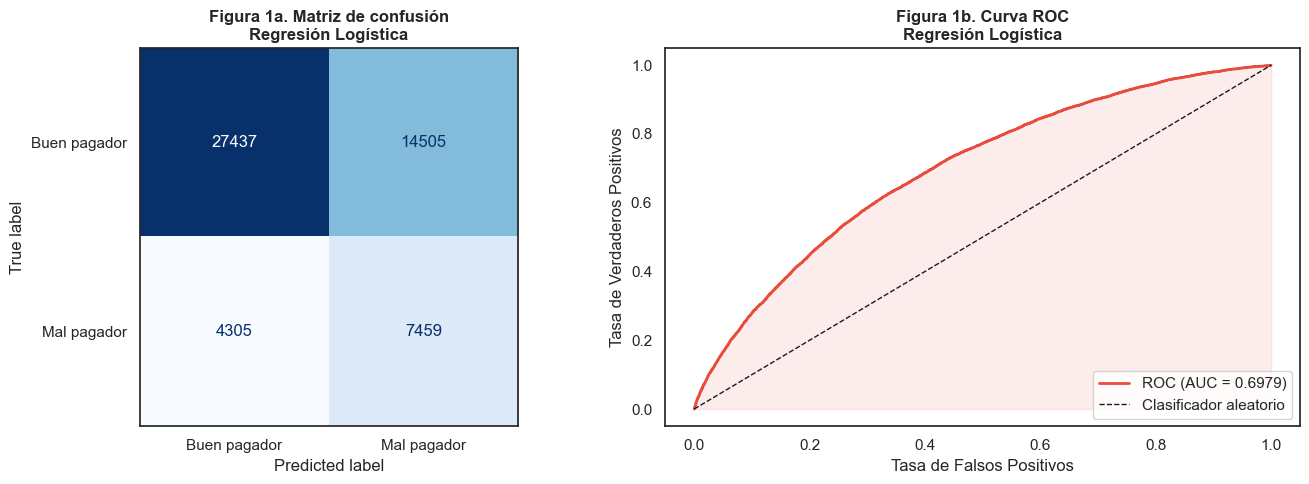

In [19]:
# Gráficos de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Buen pagador', 'Mal pagador'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Figura 1a. Matriz de confusión\nRegresión Logística',
                  fontsize=12, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Figura 1b. Curva ROC\nRegresión Logística',
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

# plt.suptitle('Figura 5. Evaluación del modelo base (Regresión Logística)',
#              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fr'{output_dir}/fig5_modelo_base.png', dpi=150, bbox_inches='tight')
plt.show()

## **5. Elaboración de la red neuronal**

### **Intento inicial**

In [20]:
# Reutilizamos X_train_scaled, X_test_scaled, y_train, y_test del modelo base

# Calculamos el class_weight para compensar el desbalance
total = len(y_train)
buenos = (y_train == 0).sum()
malos = (y_train == 1).sum()

class_weight = {
    0: total / (2 * buenos),
    1: total / (2 * malos)
}

print(f"Estos son los class weights:")
print(f"  Buen pagador (0): {class_weight[0]:.3f}")
print(f"  Mal pagador  (1): {class_weight[1]:.3f}")

Estos son los class weights:
  Buen pagador (0): 0.640
  Mal pagador  (1): 2.283


In [21]:
#Función para crear la arquitectura de la red neuronal
def build_model(input_dim, learning_rate=0.0001,
                dropout_rate=0.1, layers=[64, 32]):

    model = Sequential()

    # Capa de entrada
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(layers[0], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    # Capas ocultas
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    # Capa de salida
    model.add(Dense(1, activation='sigmoid'))

    #Compilamos el modelo
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC', 'accuracy']
    )

    return model

#Construimos el modelo
input_dim=X_train_scaled.shape[1]
model = build_model(input_dim=input_dim,
                    learning_rate=0.001,
                    dropout_rate=0.3,
                    layers=[128, 64, 32])

#Resumimos la estructura de la red
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_AUC',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_AUC',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

# Entrenamiento
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.6364 - accuracy: 0.5980 - loss: 0.7022 - val_AUC: 0.6990 - val_accuracy: 0.6540 - val_loss: 0.6104 - learning_rate: 0.0010
Epoch 2/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.6792 - accuracy: 0.6220 - loss: 0.6475 - val_AUC: 0.7026 - val_accuracy: 0.6408 - val_loss: 0.6160 - learning_rate: 0.0010
Epoch 3/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.6892 - accuracy: 0.6249 - loss: 0.6382 - val_AUC: 0.7036 - val_accuracy: 0.6427 - val_loss: 0.6147 - learning_rate: 0.0010
Epoch 4/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.6949 - accuracy: 0.6284 - loss: 0.6335 - val_AUC: 0.7044 - val_accuracy: 0.6410 - val_loss: 0.6178 - learning_rate: 0.0010
Epoch 5/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.6969 - accuracy: 0.6320 - loss: 0.6322 - val_AUC: 0.7047 - val_accuracy: 0.6383 - val_loss: 0.6207 - learning_rate: 0.0010
Epoch 6/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.6985 - accura

In [43]:
# Evaluación
y_prob_nn = model.predict(X_test_scaled).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

auc_nn = roc_auc_score(y_test, y_prob_nn)

print("\n--- Reporte de clasificación (Red Neuronal) ---")
print(classification_report(y_test, y_pred_nn,
                             target_names=['Buen pagador', 'Mal pagador']))
print(f"AUC-ROC: {auc_nn:.4f}")

1679/1679 ━━━━━━━━━━━━━━━━━━━━ 1s 561us/step

--- Reporte de clasificación (Red Neuronal) ---
              precision    recall  f1-score   support

Buen pagador       0.87      0.64      0.73     41942
 Mal pagador       0.34      0.66      0.45     11764

    accuracy                           0.64     53706
   macro avg       0.60      0.65      0.59     53706
weighted avg       0.75      0.64      0.67     53706

AUC-ROC: 0.7044


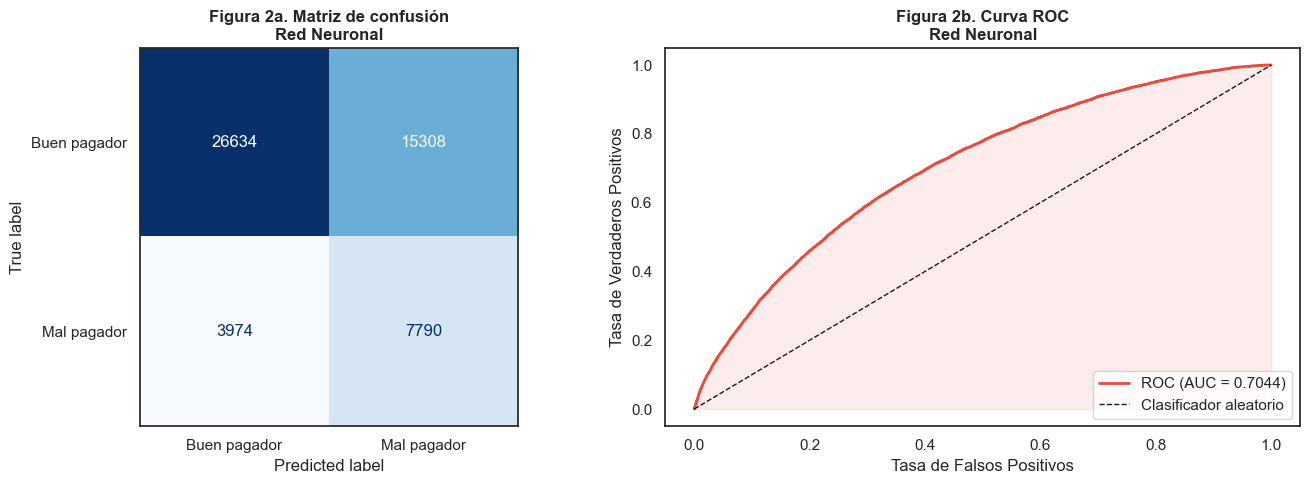

In [ ]:
# Gráficos de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Buen pagador', 'Mal pagador'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Figura 2a. Matriz de confusión\nRed Neuronal',
                  fontsize=12, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_nn)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {auc_nn:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Figura 2b. Curva ROC\nRed Neuronal',
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

# plt.suptitle('Figura 6. Evaluación del modelo base (Red Neuronal)',
#              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fr'{output_dir}/fig6_red_neuronal.png', dpi=150, bbox_inches='tight')
plt.show()

### **Modelo con SMOTE**

In [25]:
#SMOTE: Balanceo de clases por oversampling
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Distribución ANTES de SMOTE:")
print(pd.Series(y_train).value_counts())
print(f"\nDistribución DESPUÉS de SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(f"\nRegistros de entrenamiento antes: {len(y_train):,}")
print(f"Registros de entrenamiento después: {len(y_train_sm):,}")

print(f"Shape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_train_sm:     {X_train_sm.shape}")
print(f"Shape X_test_scaled:  {X_test_scaled.shape}")

Distribución ANTES de SMOTE:
target
0    167769
1     47055
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
target
0    167769
1    167769
Name: count, dtype: int64

Registros de entrenamiento antes: 214,824
Registros de entrenamiento después: 335,538
Shape X_train_scaled: (214824, 26)
Shape X_train_sm:     (335538, 26)
Shape X_test_scaled:  (53706, 26)


In [26]:
#Búsqueda combinada de arquitectura e hiperparámetros
arquitecturas = {
    'Muy profunda':  [512, 256, 128, 64, 32],
    'Embudo suave':  [128, 96, 64, 32],
    'Muy ancha':     [512, 256],
    'Ancha':         [256, 128],
    'Original':      [128, 64, 32],
}

dropouts = [0.3, 0.4, 0.5]
lrs      = [0.001, 0.0005]

combinaciones = list(itertools.product(arquitecturas.items(), dropouts, lrs))
print(f"Total combinaciones a probar: {len(combinaciones)}")

resultados_grid = []

for (nombre_arq, capas), dropout, lr in combinaciones:
    tf.random.set_seed(42)

    m = build_model(input_dim=input_dim,
                    learning_rate=lr,
                    dropout_rate=dropout,
                    layers=capas)

    m.fit(X_train_scaled, y_train,
          epochs=100,
          batch_size=512,
          validation_split=0.2,
          class_weight=class_weight,
          callbacks=[early_stopping, reduce_lr],
          verbose=0)

    proba    = m.predict(X_test_scaled).flatten()
    auc_temp = roc_auc_score(y_test, proba)
    f1_temp  = f1_score(y_test, (proba >= 0.5).astype(int), pos_label=1)

    resultados_grid.append({
        'Arquitectura':   nombre_arq,
        'Capas':          str(capas),
        'dropout':        dropout,
        'lr':             lr,
        'AUC-ROC':        round(auc_temp, 4),
        'F1 mal pagador': round(f1_temp, 4)
    })
    print(f"{nombre_arq} | dropout={dropout} | lr={lr}: AUC={auc_temp:.4f} | F1={f1_temp:.4f}")

df_grid = pd.DataFrame(resultados_grid).sort_values('AUC-ROC', ascending=False)
print("\nTop 10 combinaciones:")
print(df_grid.head(10).to_string(index=False))

mejor = df_grid.iloc[0]
mejor_arq      = arquitecturas[mejor['Arquitectura']]
mejor_dropout  = mejor['dropout']
mejor_lr       = mejor['lr']

print(f"\nMejor combinación:")
print(f"  Arquitectura: {mejor['Arquitectura']} {mejor_arq}")
print(f"  Dropout:      {mejor_dropout}")
print(f"  LR:           {mejor_lr}")
print(f"  AUC-ROC:      {mejor['AUC-ROC']}")
print(f"  F1:           {mejor['F1 mal pagador']}")

Total combinaciones a probar: 30

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
1679/1679 ━━━━━━━━━━━━━━━━━━━━ 2s 846us/step
Muy profunda | dropout=0.3 | lr=0.001: AUC=0.6951 | F1=0.4401

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
1679/1679 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Muy profunda | dropout=0.3 | lr=0.0005: AUC=0.6938 | F1=0.4357

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
1679/1679 ━━━━━━━━━━━━━━━━━━━━ 2s 956

In [27]:
#Establecemos la semilla
tf.random.set_seed(SEED)

#Creamos el modelo
model_smot = build_model(input_dim=input_dim,
                        learning_rate=mejor_lr,
                        dropout_rate=mejor_dropout,
                        layers=mejor_arq)

#Generamos la arquitectura de este
print("Arquitectura del modelo optimizado:")
model_smot.summary()

#Incluímos las callbacks
early_stopping_opt = EarlyStopping(
    monitor='val_AUC',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr_opt = ReduceLROnPlateau(
    monitor='val_AUC',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

#Entrenamos el modelo
history_opt = model_smot.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=1024,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stopping_opt, reduce_lr_opt],
    verbose=1
)

Arquitectura del modelo optimizado:


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_130 (Dense)               │ (None, 512)            │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,481 (580.00 KB)

 Trainable params: 146,945 (574.00 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.6417 - accuracy: 0.6006 - loss: 0.7307 - val_AUC: 0.6985 - val_accuracy: 0.6842 - val_loss: 0.6250 - learning_rate: 0.0010
Epoch 2/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.6817 - accuracy: 0.6237 - loss: 0.6510 - val_AUC: 0.7029 - val_accuracy: 0.6392 - val_loss: 0.6264 - learning_rate: 0.0010
Epoch 3/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6926 - accuracy: 0.6278 - loss: 0.6369 - val_AUC: 0.7042 - val_accuracy: 0.6311 - val_loss: 0.6264 - learning_rate: 0.0010
Epoch 4/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6973 - accuracy: 0.6306 - loss: 0.6319 - val_AUC: 0.7050 - val_accuracy: 0.6326 - val_loss: 0.6245 - learning_rate: 0.0010
Epoch 5/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6993 - accuracy: 0.6346 - loss: 0.6302 - val_AUC: 0.7057 - val_accuracy: 0.6337 - val_loss: 0.6227 - learning_rate: 0.0010
Epoch 6/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.7000 - 

1679/1679 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step
Umbral óptimo (máximo F1): 0.51



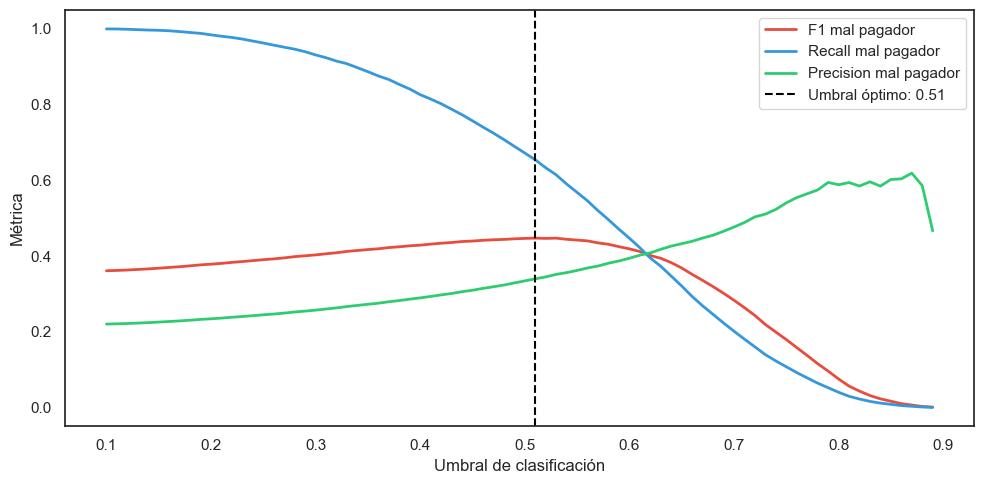

In [28]:
#Obtenemos las predicciones del modelo
y_prob_smote = model_smot.predict(X_test_scaled).flatten()

#Probaremos umbrales desde el 10% hasta el 90% con pasos de 1%
umbrales = np.arange(0.1, 0.9, 0.01)

#Almacenaremos las métricas para elegir el mejor umbral
f1_scores    = []
recall_scores = []
precision_scores = []

#Para cada umbral calculamos sus métricas y las guardamos
for u in umbrales:
    y_u = (y_prob_smote >= u).astype(int)

    # F1 solo para mal pagador (pos_label=1)
    f1_scores.append(f1_score(y_test, y_u, pos_label=1, zero_division=0))

    # Recall solo para mal pagador
    recall_scores.append(recall_score(y_test, y_u, pos_label=1, zero_division=0))

    # Precision solo para mal pagador
    precision_scores.append(precision_score(y_test, y_u, pos_label=1, zero_division=0))

#Mostramos el mejor umbral
umbral_optimo = umbrales[np.argmax(f1_scores)]
print(f"Umbral óptimo (máximo F1): {umbral_optimo:.2f}")

#Gráfico de métricas vs umbral
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, f1_scores,       label='F1 mal pagador',    color='#e74c3c', lw=2)
ax.plot(umbrales, recall_scores,   label='Recall mal pagador', color='#3498db', lw=2)
ax.plot(umbrales, precision_scores,label='Precision mal pagador', color='#2ecc71', lw=2)
ax.axvline(umbral_optimo, color='black', linestyle='--', lw=1.5,
           label=f'Umbral óptimo: {umbral_optimo:.2f}')
ax.set_xlabel('Umbral de clasificación')
ax.set_ylabel('Métrica')
# ax.set_title('Figura 7a. Métricas vs Umbral de clasificación',
#              fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(fr'{output_dir}/fig7a_umbral_optimo.png', dpi=150, bbox_inches='tight')
print()
plt.show()

In [29]:
# Evaluación del modelo optimizado
y_pred_smote = (y_prob_smote >= umbral_optimo).astype(int)
auc_opt    = roc_auc_score(y_test, y_prob_smote)

print("--- Reporte de clasificación: Red Neuronal Optimizada con SMOTE ---\n")
print(classification_report(y_test, y_pred_smote,
                             target_names=['Buen pagador', 'Mal pagador']))
print(f"AUC-ROC: {auc_opt:.4f}")
print(f"Umbral utilizado: {umbral_optimo:.2f}")

--- Reporte de clasificación: Red Neuronal Optimizada con SMOTE ---

              precision    recall  f1-score   support

Buen pagador       0.87      0.64      0.74     41942
 Mal pagador       0.34      0.65      0.45     11764

    accuracy                           0.65     53706
   macro avg       0.60      0.65      0.59     53706
weighted avg       0.75      0.65      0.68     53706

AUC-ROC: 0.7038
Umbral utilizado: 0.51


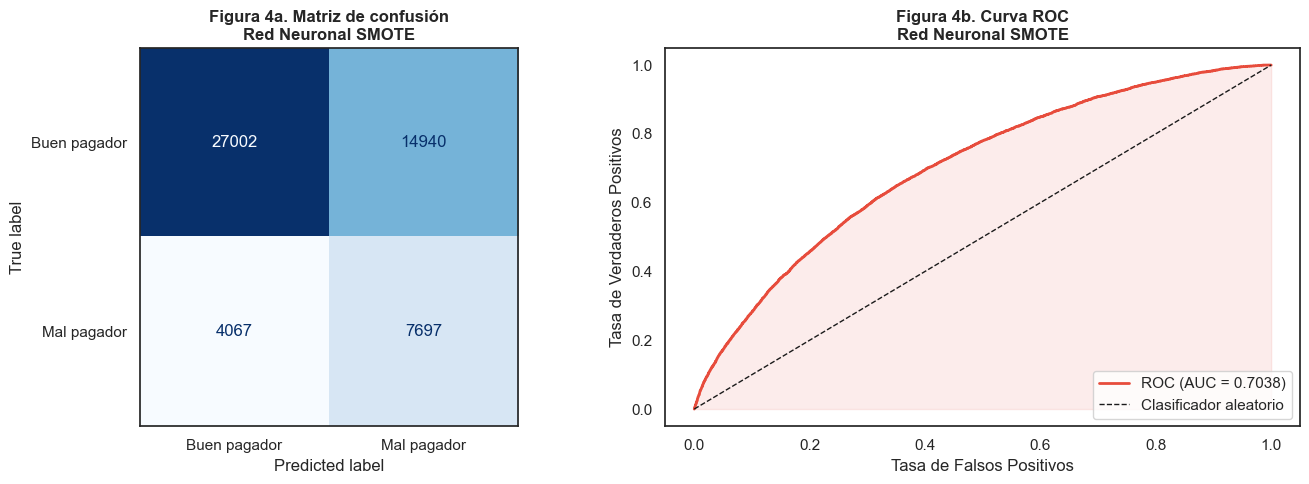

In [30]:
# Gráficos de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Buen pagador', 'Mal pagador'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Figura 4a. Matriz de confusión\nRed Neuronal SMOTE',
                  fontsize=12, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_smote)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {auc_opt:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Figura 4b. Curva ROC\nRed Neuronal SMOTE',
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(fr'{output_dir}/fig8_red_neuronal_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## **6. Scorecard del modelo**

In [ ]:
#Función para convertir la probabilidad a score
def probabilidad_a_score(probabilidad, pdo=20, score_base=600, odds_base=1):
    factor = pdo / np.log(2)
    offset = score_base - factor * np.log(odds_base)
    #Evitamos log(0) y log(1) con clip
    probabilidad = np.clip(probabilidad, 1e-6, 1 - 1e-6)
    odds = (1 - probabilidad) / probabilidad
    score = offset + factor * np.log(odds)
    #Limitamos el score al rango 300-850
    return np.clip(score, 300, 850)

# Calculamos el score para el conjunto de test
scores_test = probabilidad_a_score(y_prob_nn)

#Mostramos los resultados de los scores para los datos de testing
print("Estadísticas del score en la población de test:")
print(f"  Score mínimo:  {scores_test.min():.1f}")
print(f"  Score máximo:  {scores_test.max():.1f}")
print(f"  Score medio:   {scores_test.mean():.1f}")
print(f"  Score mediana: {np.median(scores_test):.1f}")
print(f"\nScore promedio buenos pagadores: {scores_test[y_test == 0].mean():.1f}")
print(f"Score promedio malos pagadores:  {scores_test[y_test == 1].mean():.1f}")

Estadísticas del score en la población de test:
  Score mínimo:  531.9
  Score máximo:  686.3
  Score medio:   605.3
  Score mediana: 604.1

Score promedio buenos pagadores: 608.7
Score promedio malos pagadores:  593.1


### **Distribución de scores**

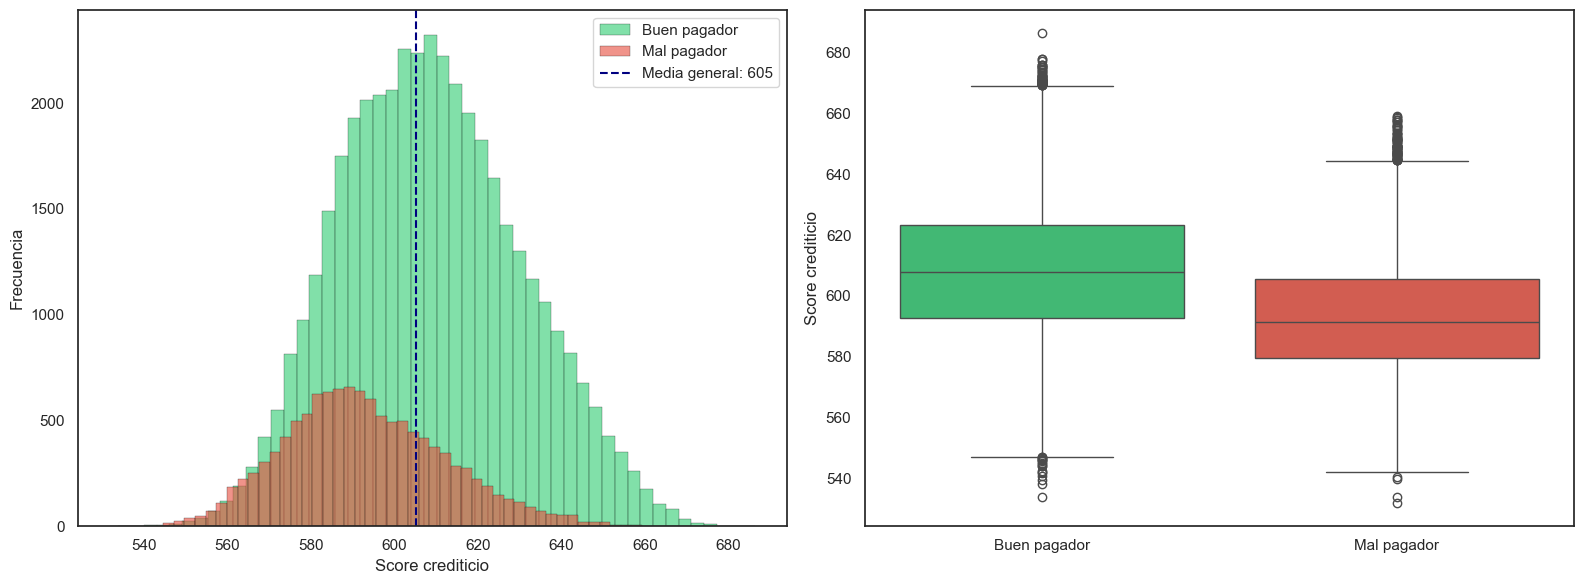

Datos de distribución guardados para la web.


In [37]:
#Distribución del score en la población
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 — Distribución general del score
axes[0].hist(scores_test[y_test == 0], bins=50, alpha=0.6,
             color='#2ecc71', label='Buen pagador', edgecolor='black', linewidth=0.3)
axes[0].hist(scores_test[y_test == 1], bins=50, alpha=0.6,
             color='#e74c3c', label='Mal pagador',  edgecolor='black', linewidth=0.3)
axes[0].axvline(scores_test.mean(), color='navy', linestyle='--', lw=1.5,
                label=f'Media general: {scores_test.mean():.0f}')
axes[0].set_xlabel('Score crediticio')
axes[0].set_ylabel('Frecuencia')
#axes[0].set_title('Figura 8a. Distribución del score por tipo de pagador',
#                  fontsize=12, fontweight='bold')
axes[0].legend()

# Gráfico 2 — Boxplot del score por tipo de pagador
df_score = pd.DataFrame({'Score': scores_test,
                          'Tipo': y_test.map({0: 'Buen pagador',
                                              1: 'Mal pagador'}).values})
sns.boxplot(data=df_score, x='Tipo', y='Score', hue='Tipo',
            palette={'Buen pagador': '#2ecc71', 'Mal pagador': '#e74c3c'},
            legend=False, ax=axes[1])
# axes[1].set_title('Figura 8b. Boxplot del score por tipo de pagador',
#                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Score crediticio')

#Detalles generales del gráfico
# plt.suptitle('Figura 8. Distribución del score crediticio',
#              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(rf'{output_dir}/fig8_distribucion_score.png', dpi=150, bbox_inches='tight')
plt.show()

# Extraemos los scores para cada grupo
scores_buenos = scores_test[y_test == 0]
scores_malos = scores_test[y_test == 1]

# En lugar de guardar miles de puntos, guardamos el histograma (frecuencias)
# Usamos los mismos bins para ambos para que cuadren en la gráfica
counts_buenos, bins = np.histogram(scores_buenos, bins=50, range=(300, 850))
counts_malos, _ = np.histogram(scores_malos, bins=50, range=(300, 850))

datos_grafica = {
    "bins": bins.tolist(),
    "counts_buenos": counts_buenos.tolist(),
    "counts_malos": counts_malos.tolist(),
    "media_general": float(scores_test.mean()),
    # Guardamos también datos para el boxplot (cuartiles, etc.)
    "stats_buenos": {
        "min": float(scores_buenos.min()),
        "q1": float(np.percentile(scores_buenos, 25)),
        "mediana": float(np.median(scores_buenos)),
        "q3": float(np.percentile(scores_buenos, 75)),
        "max": float(scores_buenos.max())
    },
    "stats_malos": {
        "min": float(scores_malos.min()),
        "q1": float(np.percentile(scores_malos, 25)),
        "mediana": float(np.median(scores_malos)),
        "q3": float(np.percentile(scores_malos, 75)),
        "max": float(scores_malos.max())
    }
}

with open(fr'output/datos_distribucion.json', 'w') as f:
    json.dump(datos_grafica, f)

print("Datos de distribución guardados para la web.")

### **Segmentación por nivel de riesgo**

Tabla de segmentación por nivel de riesgo:
                 Clientes  Score_medio  Tasa_incumplimiento  % Población
Segmento                                                                
Muy bajo riesgo      3875        649.1                  4.4          7.2
Bajo riesgo         13399        625.5                 10.5         24.9
Riesgo medio        22189        602.4                 21.0         41.3
Riesgo alto         12996        580.6                 37.0         24.2
Muy alto riesgo      1247        559.3                 58.3          2.3



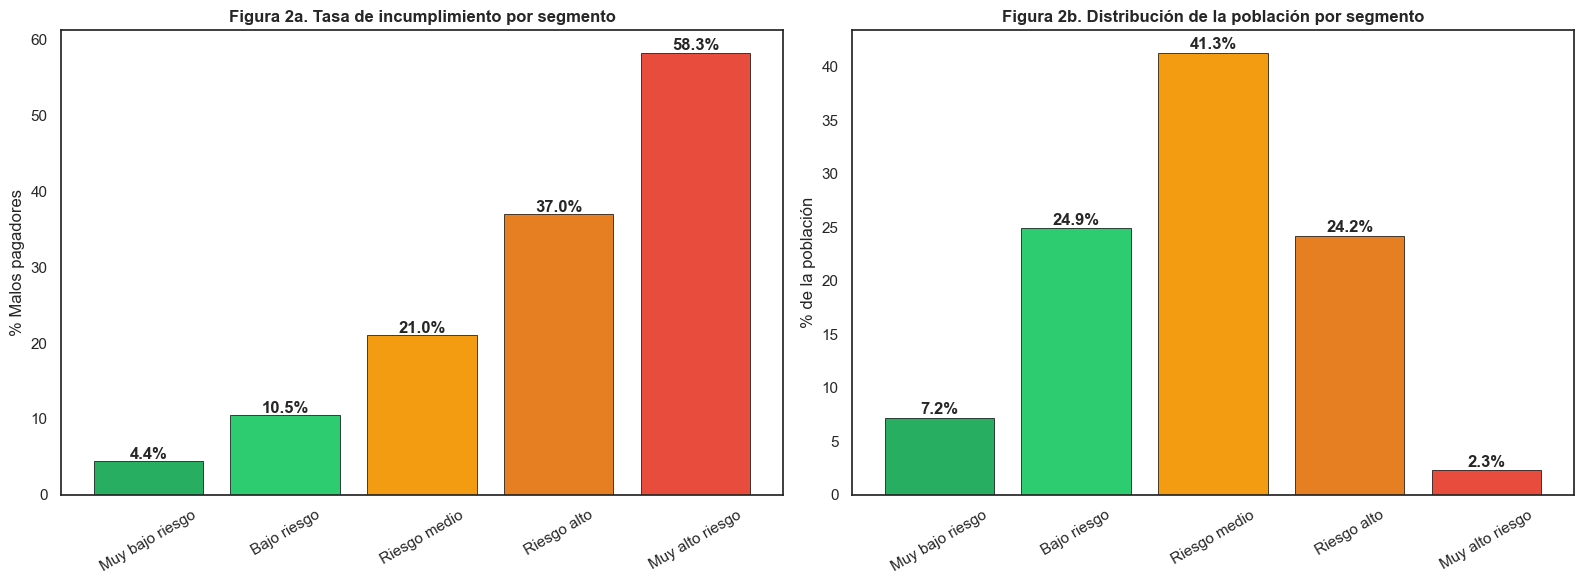

In [38]:
#Función para segmentar clientes según su score
def segmentar_riesgo(score):
    if score >= 640:
        return 'Muy bajo riesgo'  # El tope de la distribución (percentil alto)
    elif score >= 615:
        return 'Bajo riesgo'      # Por encima de la media
    elif score >= 590:
        return 'Riesgo medio'     # Alrededor de la media (zona de mayor solapamiento)
    elif score >= 565:
        return 'Riesgo alto'      # Inicio de la zona de predominancia de mal pagador
    else:
        return 'Muy alto riesgo'  # Cola izquierda de la distribución

#Utilizamos un Dataframe sobre los scores de la población del conjunto de testing
df_score['Segmento'] = df_score['Score'].apply(segmentar_riesgo)
df_score['target'] = y_test.values

#Establecemos el orden de los segmentos
orden_segmentos = ['Muy bajo riesgo', 'Bajo riesgo',
                   'Riesgo medio', 'Riesgo alto', 'Muy alto riesgo']

# Estadísticas por segmento
resumen = df_score.groupby('Segmento').agg(
    Clientes=('Score', 'count'),
    Score_medio=('Score', 'mean'),
    Tasa_incumplimiento=('target', 'mean')
).reindex(orden_segmentos)

resumen['Tasa_incumplimiento'] = (resumen['Tasa_incumplimiento'] * 100).round(1)
resumen['Score_medio'] = resumen['Score_medio'].round(1)
resumen['% Población'] = (resumen['Clientes'] / len(df_score) * 100).round(1)

#Generamos un resumen de la segmentación por nivel de riesgo
print("Tabla de segmentación por nivel de riesgo:")
print(resumen.to_string())

# Gráfico de tasa de incumplimiento por segmento
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores_seg = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

axes[0].bar(orden_segmentos, resumen['Tasa_incumplimiento'],
            color=colores_seg, edgecolor='black', linewidth=0.5)
axes[0].set_title('Figura 2a. Tasa de incumplimiento por segmento',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Malos pagadores')
axes[0].tick_params(axis='x', rotation=30)
for i, val in enumerate(resumen['Tasa_incumplimiento']):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

axes[1].bar(orden_segmentos, resumen['% Población'],
            color=colores_seg, edgecolor='black', linewidth=0.5)
axes[1].set_title('Figura 2b. Distribución de la población por segmento',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% de la población')
axes[1].tick_params(axis='x', rotation=30)
for i, val in enumerate(resumen['% Población']):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

#Elementos generales del gráfico
# plt.suptitle('Figura 8. Segmentación por nivel de riesgo',
#              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(rf'{output_dir}/fig8_segmentacion_riesgo.png', dpi=150, bbox_inches='tight')
print()
plt.show()

### **Importancia de variables**

Calculando importancia para 26 variables...


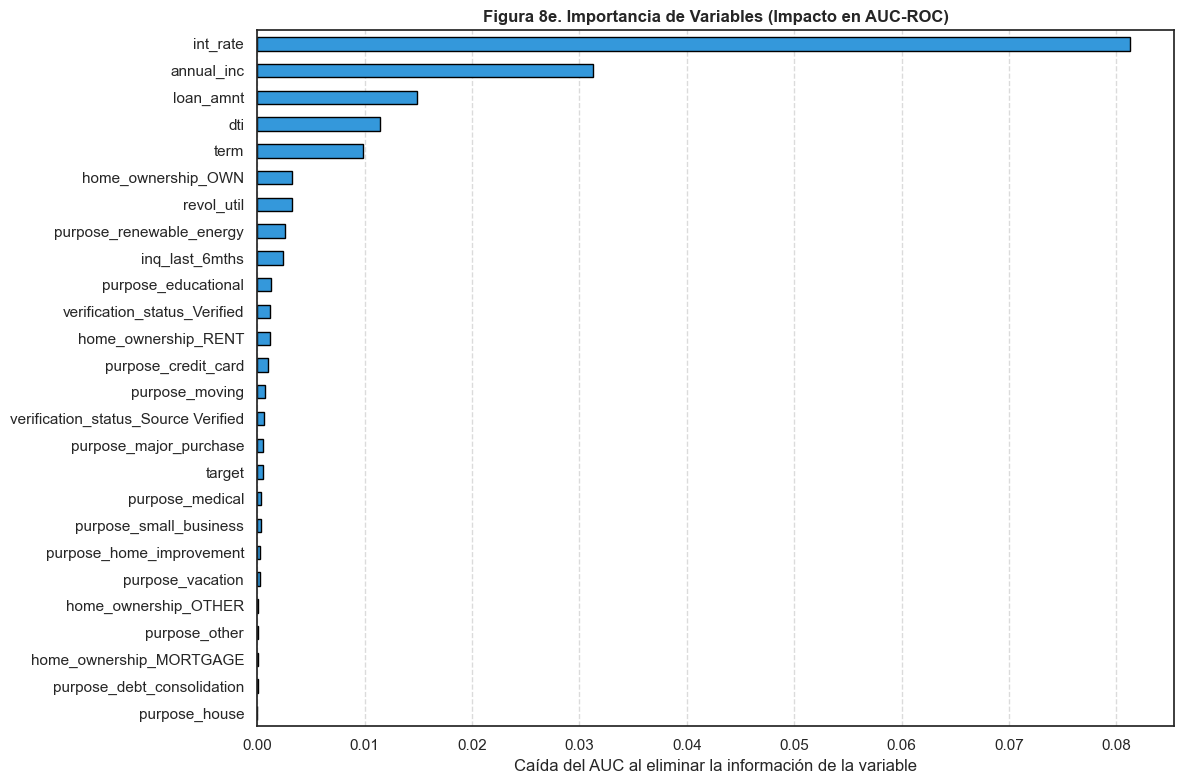


Top Variables por importancia:
int_rate                               0.081296
annual_inc                             0.031270
loan_amnt                              0.014880
dti                                    0.011470
term                                   0.009824
home_ownership_OWN                     0.003244
revol_util                             0.003201
purpose_renewable_energy               0.002559
inq_last_6mths                         0.002411
purpose_educational                    0.001265
verification_status_Verified           0.001166
home_ownership_RENT                    0.001154
purpose_credit_card                    0.001015
purpose_moving                         0.000683
verification_status_Source Verified    0.000578
purpose_major_purchase                 0.000569
target                                 0.000560
purpose_medical                        0.000329
purpose_small_business                 0.000303
purpose_home_improvement               0.000275
purpose_

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# 1. Definimos la función de evaluación
def get_score(X, y):
    # Usamos verbose=0 para que no llene la pantalla de barras de carga
    y_pred = model.predict(X, verbose=0).flatten()
    return roc_auc_score(y, y_pred)

# 2. Aseguramos que la lista de nombres coincida con el número de columnas de la matriz
# Si vars_disponibles es más larga que las columnas de X, tomamos solo las primeras N
n_columnas = X_test_scaled.shape[1]
nombres_validos = vars_disponibles[:n_columnas]

# 3. Calculamos el baseline
baseline_auc = get_score(X_test_scaled, y_test)
importancias = {}

print(f"Calculando importancia para {n_columnas} variables...")

# 4. Bucle de permutación corregido
for i in range(n_columnas):
    var = nombres_validos[i]
    X_permuted = X_test_scaled.copy()
    
    # Desordenamos la columna i de forma aleatoria
    np.random.shuffle(X_permuted[:, i])
    
    # Evaluamos el impacto
    permuted_auc = get_score(X_permuted, y_test)
    importancias[var] = baseline_auc - permuted_auc

# 5. Visualización
importancia_vars = pd.Series(importancias).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
importancia_vars.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')

ax.set_title('Figura 8e. Importancia de Variables (Impacto en AUC-ROC)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Caída del AUC al eliminar la información de la variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Ranking en texto
print("\nTop Variables por importancia:")
print(importancia_vars.sort_values(ascending=False).to_string())

### **Ejemplo de scoring**

In [45]:
for i, idx in enumerate(ejemplos_idx):
    cliente = X_test.loc[idx]
    realidad = y_test.loc[idx]
    
    # 1. Recuperar la probabilidad
    pos_entera = X_test.index.get_loc(idx)
    prob = y_prob_nn[pos_entera]
    score = probabilidad_a_score(np.array([prob]))[0]
    segmento = segmentar_riesgo(score)
    
    # 2. RECONSTRUIR EL PROPÓSITO
    columnas_purpose = [col for col in X_test.columns if col.startswith('purpose_')]
    proposito_real = "Otro"
    for col in columnas_purpose:
        if cliente[col] == 1:
            proposito_real = col.replace('purpose_', '').replace('_', ' ').capitalize()
            break

    # 3. Formatear resultados (Sustituyendo antigüedad por variables clave)
    prediccion = 'Buen pagador' if prob < 0.5 else 'Mal pagador'
    realidad_str = 'Buen pagador' if realidad == 0 else 'Mal pagador'
    
    # NUEVAS VARIABLES CLAVE BASADAS EN EL EDA
    tasa = cliente.get('int_rate', 0)
    uso_credito = cliente.get('revol_util', 0)
    dti = cliente.get('dti', 0)

    print(f"\n👤 CASO {i+1}: {nombres_blog[i]} (ID: {idx})")
    print(f"   Datos de Entrada (Perfil de Riesgo):")
    print(f"   • Propósito detectado:  {proposito_real}")
    print(f"   • Tasa de Interés:      {tasa:.2f}%") # Variable con mayor correlación (0.255)
    print(f"   • Utilización Revol.:   {uso_credito:.2f}%") # Indicador de estrés financiero
    print(f"   • Relación Deuda (DTI): {dti:.2f}%")
    
    print(f"\n   Métricas del Scorecard:")
    print(f"   • Score Calculado:       {score:.0f} pts")
    print(f"   • Segmento:              {segmento.upper()}")
    
    print(f"\n   Validación:")
    print(f"   • Realidad:    {realidad_str}")
    status = '✅ ACIERTO' if prediccion == realidad_str else '❌ ERROR'
    print(f"   • Resultado:   {status}")
    print("-" * 65)


👤 CASO 1: María López (ID: 227402)
   Datos de Entrada (Perfil de Riesgo):
   • Propósito detectado:  Debt consolidation
   • Tasa de Interés:      6.62%
   • Utilización Revol.:   64.60%
   • Relación Deuda (DTI): 8.14%

   Métricas del Scorecard:
   • Score Calculado:       631 pts
   • Segmento:              BAJO RIESGO

   Validación:
   • Realidad:    Buen pagador
   • Resultado:   ✅ ACIERTO
-----------------------------------------------------------------

👤 CASO 2: Carlos Ríos (ID: 33913)
   Datos de Entrada (Perfil de Riesgo):
   • Propósito detectado:  Home improvement
   • Tasa de Interés:      13.92%
   • Utilización Revol.:   37.40%
   • Relación Deuda (DTI): 13.10%

   Métricas del Scorecard:
   • Score Calculado:       619 pts
   • Segmento:              BAJO RIESGO

   Validación:
   • Realidad:    Buen pagador
   • Resultado:   ✅ ACIERTO
-----------------------------------------------------------------

👤 CASO 3: Alejandra Paredes (ID: 723670)
   Datos de Entrada (Perf